<a href="https://colab.research.google.com/github/GyeongHub/ESAA-OB/blob/main/week10_0509_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*0509(금) 10주차 과제*\
*딥러닝 파이토치 교과서 2장 실습 환경 설정과 파이토치 기초 - 04  p.69-87*

# 2.4 파이토치 코드 맛보기

**라이브러리 설명**
1.  matplotlib: 2D, 3D 형태의 그래프를 그릴 때 주로 사용
2. seaborn: 데이터 프레임으로 다양한 통계 지표를 표현할 수 있는 시각화 차트를 제공
3. scikit-learn: 분류/회귀/군집/의사 결정 트리 등 다양한 머신 러닝 알고리즘을 적용할 수 있는 함수를 제공하는 머신 러닝 라이브러리

---

> 1~6의 칼럼 정보를 이용해 output(차 상태)을 예측

In [7]:
# 필요한 라이브러리 호출

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [8]:
# 데이터 로드
from google.colab import drive
drive.mount('/content/drive')

dataset = pd.read_csv('/content/drive/MyDrive/ESAA-OB/data/car_evaluation.csv')

dataset.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


<Axes: ylabel='count'>

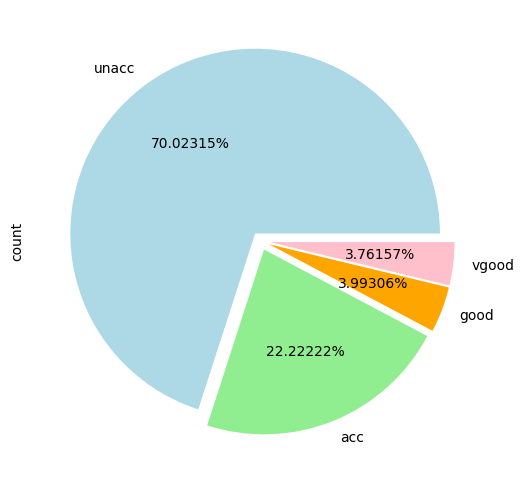

In [10]:
# 예제 데이터셋 분포 시각화

fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size
dataset.output.value_counts().plot(kind='pie', autopct='%0.05f%%',
                                   colors=['lightblue', 'lightgreen', 'orange', 'pink'],
                                   explode=(0.05, 0.05, 0.05, 0.05))

    -> 대부분의 자동차는 허용 불가능한 상태에 있고 20%만 허용 가능한 수준.

---

**범주형 데이터을 텐서로 변환하는 절차**

범주형 데이터 -> dataset[category] -> 넘파이 배열 -> 텐서

In [17]:
# 전처리: 데이터를 범주형 타입으로 변환

categorical_columns = ['price', 'maint',
                       'doors', 'persons',
                       'lug_capacity', 'safety']  # 예제 데이터셋 칼럼들의 목록

for category in categorical_columns:
    dataset[category] = dataset[category].astype('category') # astype() 메서드 -> 데이터를 범주형으로 변환

price = dataset['price'].cat.codes.values         # [1]
maint = dataset['maint'].cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values

categorical_data = np.stack([price, maint, doors, persons, lug_capacity, safety], 1)    # [2]
categorical_data[:10]  # 합친 넘파이 배열 중 10개의 행 출력

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

    # [1]: 범주형 데이터(단어)를 숫자(넘파이 배열)로 변환하기 위해 cat.codes를 사용

    # [2]: np.stack은 두 개 이상의 넘파이 객체를 합칠 때 사용

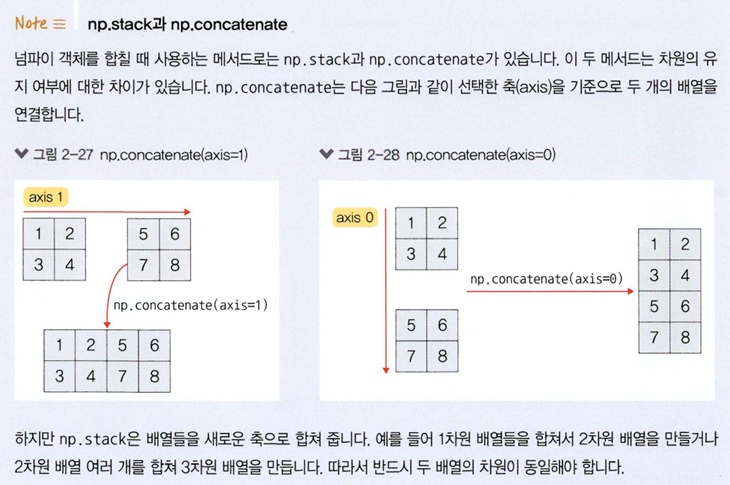

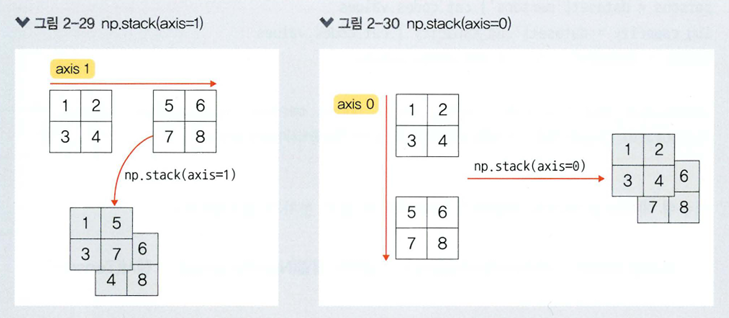

In [18]:
# torch 모듈을 이용하여 배열을 텐서로 변환

categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [19]:
# 레이블로 사용할 칼럼을 텐서로 변환

outputs = pd.get_dummies(dataset.output)    # [1]
outputs = outputs.values
outputs = torch.tensor(outputs).flatten()   # 1차원 텐서로 변환

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


    # [1] get_dummies는 가변수(dummy variable)로 만들어 주는 함수. 즉, 문자를 숫자 (0, 1)로 바꾸어 준다는 의미.

In [20]:
# get_dummies 예제

import numpy as np
import pandas as pd

data = {
    'gender': ['male', 'female', 'male'],
    'weight': [72, 55, 68],
    'nation': ['Japan', 'Korea', 'Australia']
}

df = pd.DataFrame(data)
df

,gender,weight,nation
0,male,72,Japan
1,female,55,Korea
2,male,68,Australia


In [21]:
pd.get_dummies(df)

,weight,gender_female,gender_male,nation_Australia,nation_Japan,nation_Korea
0,72,False,True,False,True,False
1,55,True,False,False,False,True
2,68,False,True,True,False,False


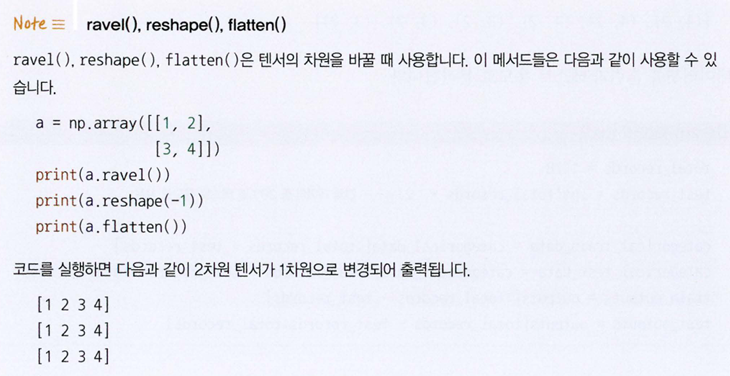

> 워드 임베딩: 유사한 단어끼리 유사하게 인코딩되도록 표현하는 방법\
    - 배열을 N차원으로 변환하기 위해 먼저 모든 범주형 칼럼에 대한 임베딩 크기(벡터 차원)를 정의 \
    - 임베딩 크기에 대한 정확한 규칙은 없지만 칼럼의 고유 값 수를 2로 나누는 것을 많이 사용

In [22]:
# 범주형 칼럼을 N차원으로 변환

categorical_column_sizes = [len(dataset[column].cat.categories) for
                            column in categorical_columns]
categorical_embedding_sizes = [(col_size, min(50, (col_size+1)//2)) for
                               col_size in categorical_column_sizes]

print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [26]:
# 데이터셋 분리

total_records = 1728
test_records = int(total_records * .2)   # 전체 데이터 중 20%를 테스트 용도로 사용

categorical_train_data = categorical_data[:total_records - test_records]
categorical_test_data = categorical_data[total_records - test_records:total_records]

train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

In [27]:
# 데이터셋 분리 확인

print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


In [30]:
# 모델의 네트워크 생성

class Model(nn.Module): # [1]
    def __init__(self, embedding_size, output_size, layers, p=0.4):  # [2]
        super().__init__()  # [3]
        self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for
                                         ni, nf in embedding_size])
        self.embedding_dropout = nn.Dropout(p)

        all_layers = []
        num_categorical_cols = sum((nf for ni, nf in embedding_size))
        input_size = num_categorical_cols

        for i in layers:  # [4]
            all_layers.append(nn.Linear(input_size, i))
            all_layers.append(nn.ReLU(inplace = True))
            all_layers.append(nn.BatchNorm1d(i))
            all_layers.append(nn.Dropout(p))
            input_size = i

        all_layers.append(nn.Linear(layers[-1], output_size))
        self.layers = nn.Sequential(*all_layers)

    def forward(self, x_categorical):  # [5]
        embeddings = []
        for i,e in enumerate(self.all_embeddings):
            embeddings.append(e(x_categorical[:, i]))

        x = torch.cat(embeddings, 1)
        x = self.embedding_dropout(x)
        x = self.layers(x)
        return x

    # [1] 클래스(class) 형태로 구현되는 모델은 nn.Module을 상속받음
    # [2] __init__()은 모델에서 사용될 파라미터와 신경망을 초기화하기 위한 용도로 사용하며, 객체가 생성될 때 자동으로 호출됨.
    # [3] super().__init__()은 부모 클래스(nn.Module)에 접근할 때 사용.
    # [4] 모델의 네트워크 계층을 구축하기 위해 for 문을 이용하여 각 계층을 all_layers 목록에 추가.
    # [5]  forward() 함수: 학습 데이터를 입력받아서 연산을 진행. 모델 객체를 데이터와 함께 호출하면 자동으로 실행됨.  

- `__init__()`에서 전달되는 매개변수

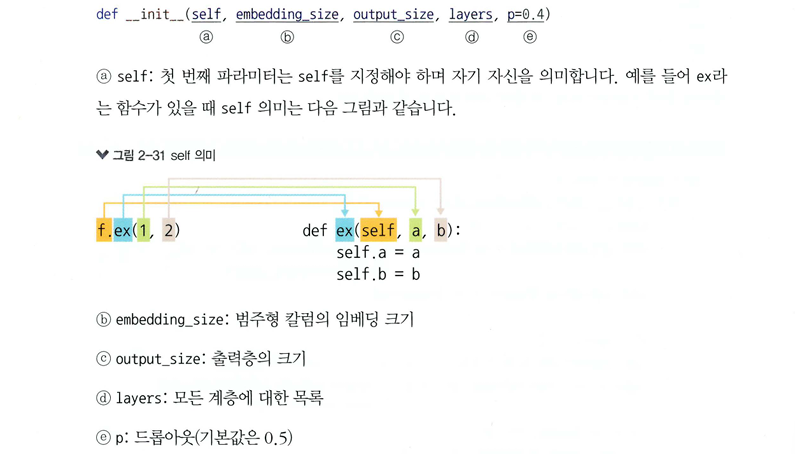

- 추가된 계층

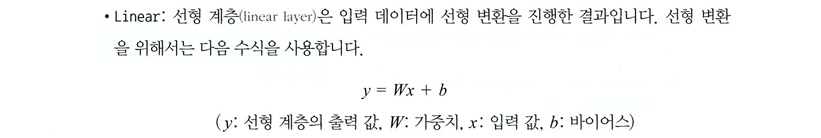

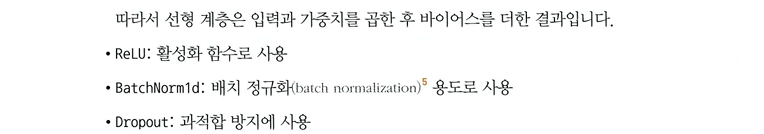

In [31]:
# Model 클래스의 객체 생성

model = Model(categorical_embedding_sizes, 4, [200,100,50], p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


In [32]:
# 모델의 파라미터 정의

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [35]:
# CPU/GPU 사용 지정

if torch.cuda.is_available():
    device = torch.device('cuda')  # GPU가 있으면 GPU 사용
else:
    device = torch.device('cpu')   # 없으면 CPU 사용

In [36]:
# 모델 학습

epochs = 500
aggregated_losses = []
train_outputs = train_outputs.to(device=device, dtype=torch.int64)

for i in range(epochs):   # for문은 500회 반복되며, 각 반복마다 손실 함수가 오차를 계산
    i += 1
    y_pred = model(categorical_train_data).to(device)
    single_loss = loss_function(y_pred, train_outputs)
    aggregated_losses.append(single_loss)   # 반복할 때마다 오치를 aggregated_losses에 추가

    if i%25 == 1:
        print(f'epoch: {1:3} loss: {single_loss.item():10.8f}')

    optimizer.zero_grad()
    single_loss.backward()   # 가중치를 업데이트하기 위해 손실 함수의 backward() 메서드 호출
    optimizer.step()         # 옵티마이저 함수의 step() 메서드를 이용하여 기울기 업데이트

print(f'epoch: {1:3} loss: {single_loss.item():10.10f}')  # 오차가 25 에포크마다 출력

epoch:   1 loss: 1.54253066
epoch:   1 loss: 1.36479843
epoch:   1 loss: 1.28208804
epoch:   1 loss: 1.17444146
epoch:   1 loss: 1.05303848
epoch:   1 loss: 0.92057925
epoch:   1 loss: 0.80034918
epoch:   1 loss: 0.73801714
epoch:   1 loss: 0.69626945
epoch:   1 loss: 0.66636747
epoch:   1 loss: 0.63292432
epoch:   1 loss: 0.61835408
epoch:   1 loss: 0.60386485
epoch:   1 loss: 0.58439249
epoch:   1 loss: 0.58613330
epoch:   1 loss: 0.59170991
epoch:   1 loss: 0.58006287
epoch:   1 loss: 0.58621502
epoch:   1 loss: 0.58327395
epoch:   1 loss: 0.57109606
epoch:   1 loss: 0.5706615448


In [37]:
# 테스트 데이터셋으로 모델 예측

test_outputs = test_outputs.to(device = device, dtype=torch.int64)
with torch.no_grad():
    y_val = model(categorical_test_data)
    loss = loss_function(y_val, test_outputs)
print(f'Loss: {loss:.8f}')

Loss: 0.56510377


    이 값은 훈련 데이터셋에서 도출된 손실 값과 비슷하므로 과적합은 발생하지 않았다고 판단할 수 있음.

In [38]:
# 모델의 예측 확인

print(y_val[:5])

tensor([[ 3.2653,  2.0625, -3.4854, -3.0372],
        [ 2.9342,  1.6976, -2.9850, -2.7746],
        [ 3.5164,  2.1395, -3.2012, -3.1983],
        [ 3.3334,  2.0705, -3.4153, -3.4883],
        [ 1.7822,  1.0168, -2.9214, -2.6001]])


>  모델 네트워크의 output_size = 4 지정. 출력층에 네 개의 뉴런이 포함되도록 지정했으므로 각 예측에는 네 개의 값이 포함됨.

In [39]:
# 가장 큰 값을 갖는 인덱스 확인

y_val = np.argmax(y_val, axis=1)
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


    출력 결과 모두 인덱스 0이 출력. 인덱스가 0인 값이 인덱스가 1인 값보다 크므로 처리된 출력이 O임을 확인할 수 있음.

In [40]:
# 테스트 데이터셋을 이용한 정확도 확인

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(test_outputs, y_val))
print(classification_report(test_outputs, y_val))
print(accuracy_score(test_outputs, y_val))

[[259   0]
 [ 84   2]]
              precision    recall  f1-score   support

           0       0.76      1.00      0.86       259
           1       1.00      0.02      0.05        86

    accuracy                           0.76       345
   macro avg       0.88      0.51      0.45       345
weighted avg       0.82      0.76      0.66       345

0.7565217391304347


---

> 성능 평가 지표 \
- 정확도(accuracy)
- 재현율(recall)
- 정밀도(precision)
- F1-score

- True Positive: 예측=1, 실제=1
- True Negative: 예측=0, 실제=0
- False Positive: 예측=1, 실제=0 (Type1 Error)
- False Negative: 예측=0, 실제=1 (Type2 Error)

**정확도**

전체 예측 건수에서 정답을 맞힌 건수의 비율

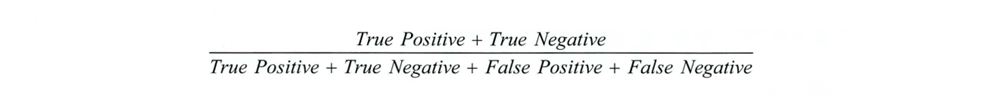

**재현율**

실제로 정답이 1일 때, 모델도 1로 예측한 비율

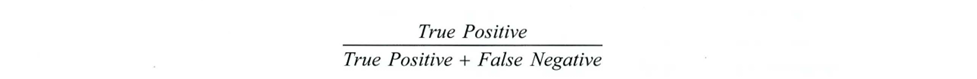

**정밀도**

모델이 1이라고 예측한 것 중에서 실제로 정답이 1인 비율

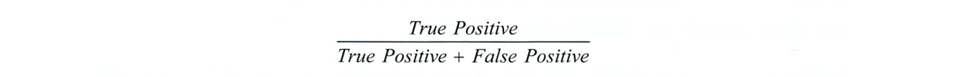

**F1-score**

정밀도와 재현율의 조화 평균(hannonic mean)

*일반적으로 정밀도와 재현율은 트레이드오프 관계. 이 문제를 해결하고자 하는 평가 지수.

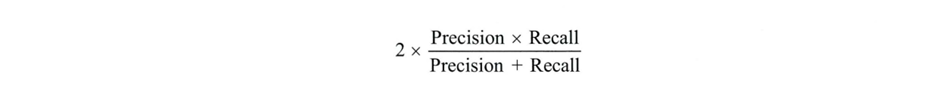